In [ ]:
import numpy as np
import pandas as pd
import fastbox as fb
import os
from datetime import timedelta, time
# server 0: math cluster server, server 1: math server, server 2: ali server, server 3: local server 
# among them, server 2 can be accessed from outside the campus, 0 and 1 are faster
fb.login(os.environ['FASTBOX_USERNAME'], os.environ['FASTBOX_PASSWORD'])

User authorized.

## 期货基本信息与数据的获取

In [ ]:
info_df = fb.data.futures.info(instrumentid = 'CU2311')
info_df

,underlyingid,exchange,name,multiplier,trade_unit,per_unit,quote_unit,quote_unit_desc,d_mode_desc,list_date,delist_date,d_month,last_ddate,zhenzhouid
instrumentid,,,,,,,,,,,,,,
CU2311,CU,SHFE,沪铜2311,None,吨,5.0,人民币元/吨,10人民币元/吨,实物交割,2022-11-16 09:30:00+08:00,2023-11-15 15:30:00+08:00,202311,2023-11-17 15:30:00+08:00,CU2311


In [ ]:
# call LV2 data for a future on an interval (be aware of data limit)
data = fb.data.futures.lv2(
        instrumentid = 'CU2311',
        from_date = '2023-10-16',
        to_date = '2023-10-31'
        )
data.drop(columns=['amount'], inplace=True)
data

,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,va2,...,pa5,va5,open,highest,lowest,oi,avg_price,up_limit,dn_limit,instrumentid
trade_time,,,,,,,,,,,,,,,,,,,,,
2023-10-16 08:59:00.500000+08:00,66180.0,31439.0,66170.0,1.0,66180.0,13.0,66160.0,27.0,66190.0,5.0,...,66220.0,22.0,66420.0,66450.0,65890.0,162108.0,330822.0,70410.0,62440.0,CU2311
2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,3.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162123.0,330822.0,70410.0,62440.0,CU2311
2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,4.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162150.0,330822.0,70410.0,62440.0,CU2311
2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,25.0,...,66250.0,22.0,66420.0,66450.0,65890.0,162156.0,330822.0,70410.0,62440.0,CU2311
2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,18.0,...,66260.0,18.0,66420.0,66450.0,65890.0,162155.0,330822.0,70410.0,62440.0,CU2311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-31 23:59:32+08:00,67330.0,2305.0,67440.0,5.0,67470.0,15.0,67430.0,5.0,67480.0,20.0,...,67520.0,10.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
2023-10-31 23:59:32.500000+08:00,67330.0,2305.0,67440.0,20.0,67470.0,20.0,67430.0,5.0,67480.0,5.0,...,67520.0,10.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
2023-10-31 23:59:33.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,5.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311


In [4]:
data.reset_index(inplace=True)
data.columns

Index(['trade_time', 'last_price', 'vol', 'pb1', 'vb1', 'pa1', 'va1', 'pb2',
       'vb2', 'pa2', 'va2', 'pb3', 'vb3', 'pa3', 'va3', 'pb4', 'vb4', 'pa4',
       'va4', 'pb5', 'vb5', 'pa5', 'va5', 'open', 'highest', 'lowest', 'oi',
       'avg_price', 'up_limit', 'dn_limit', 'instrumentid'],
      dtype='object')

### 1. 补充缺失值

In [5]:
full_time_index = pd.date_range(start=data['trade_time'].min(), end=data['trade_time'].max(), freq='500ms')

# 定义交易时段的函数
def is_in_trading_hours(dt):
    if time(9, 0) <= dt.time() <= time(10, 15):
        return True
    elif time(10, 30) <= dt.time() <= time(11, 30):
        return True
    elif time(13, 30) <= dt.time() <= time(14, 55):
        return True
    elif (time(21, 0) <= dt.time()) or (dt.time() <= time(0, 55)):
        return True
    return False
    
# 筛选交易时段内的时间点
full_time_index = [pd.Timestamp(dt).tz_convert('Asia/Shanghai') for dt in full_time_index if is_in_trading_hours(dt)]
len(full_time_index)

867056

In [6]:
data = data.set_index('trade_time').reindex(full_time_index)
data = data.ffill()  # 填充前值
data.dropna(inplace=True)
data.reset_index(inplace=True)
data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,pa5,va5,open,highest,lowest,oi,avg_price,up_limit,dn_limit,instrumentid
0,2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162123.0,330822.0,70410.0,62440.0,CU2311
1,2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162150.0,330822.0,70410.0,62440.0,CU2311
2,2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,...,66250.0,22.0,66420.0,66450.0,65890.0,162156.0,330822.0,70410.0,62440.0,CU2311
3,2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,...,66260.0,18.0,66420.0,66450.0,65890.0,162155.0,330822.0,70410.0,62440.0,CU2311
4,2023-10-16 09:00:02.500000+08:00,66220.0,31557.0,66200.0,2.0,66220.0,20.0,66190.0,2.0,66230.0,...,66260.0,19.0,66420.0,66450.0,65890.0,162152.0,330823.0,70410.0,62440.0,CU2311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867050,2023-10-31 23:59:54+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867051,2023-10-31 23:59:54.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867052,2023-10-31 23:59:55+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867053,2023-10-31 23:59:55.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311


### 2. 删除重复值

In [7]:
data.sort_values(by='trade_time', inplace=True)
data.drop_duplicates(subset='trade_time', keep='first', inplace=True)
data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,pa5,va5,open,highest,lowest,oi,avg_price,up_limit,dn_limit,instrumentid
0,2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162123.0,330822.0,70410.0,62440.0,CU2311
1,2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162150.0,330822.0,70410.0,62440.0,CU2311
2,2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,...,66250.0,22.0,66420.0,66450.0,65890.0,162156.0,330822.0,70410.0,62440.0,CU2311
3,2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,...,66260.0,18.0,66420.0,66450.0,65890.0,162155.0,330822.0,70410.0,62440.0,CU2311
4,2023-10-16 09:00:02.500000+08:00,66220.0,31557.0,66200.0,2.0,66220.0,20.0,66190.0,2.0,66230.0,...,66260.0,19.0,66420.0,66450.0,65890.0,162152.0,330823.0,70410.0,62440.0,CU2311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867050,2023-10-31 23:59:54+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867051,2023-10-31 23:59:54.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867052,2023-10-31 23:59:55+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867053,2023-10-31 23:59:55.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311


### 3. 处理异常值

In [ ]:
## 情况一：vol为0时，对avg_price进行调整，赋值为last_price
data.loc[data['vol'] == 0, 'avg_price'] = data['last_price']
data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,pa5,va5,open,highest,lowest,oi,avg_price,up_limit,dn_limit,instrumentid
0,2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162123.0,330822.0,70410.0,62440.0,CU2311
1,2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162150.0,330822.0,70410.0,62440.0,CU2311
2,2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,...,66250.0,22.0,66420.0,66450.0,65890.0,162156.0,330822.0,70410.0,62440.0,CU2311
3,2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,...,66260.0,18.0,66420.0,66450.0,65890.0,162155.0,330822.0,70410.0,62440.0,CU2311
4,2023-10-16 09:00:02.500000+08:00,66220.0,31557.0,66200.0,2.0,66220.0,20.0,66190.0,2.0,66230.0,...,66260.0,19.0,66420.0,66450.0,65890.0,162152.0,330823.0,70410.0,62440.0,CU2311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867050,2023-10-31 23:59:54+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867051,2023-10-31 23:59:54.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867052,2023-10-31 23:59:55+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311
867053,2023-10-31 23:59:55.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,337026.0,71520.0,63430.0,CU2311


In [9]:
data['avg_price'] = data['avg_price']/5
## 情况二：开高低收等价格信息出现异常值
price_cols = ['last_price', 'pb1', 'pa1', 'pb2', 'pa2', 'pb3', 'pa3', 'pb4', 'pa4', 'pb5', 'pa5', 'open', 'highest', 'lowest', 'avg_price']
for p_col in price_cols:
    data.loc[data[p_col] > data['up_limit'], p_col] = np.nan
    data.loc[data[p_col] < data['dn_limit'], p_col] = np.nan
data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,pa5,va5,open,highest,lowest,oi,avg_price,up_limit,dn_limit,instrumentid
0,2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162123.0,66164.4,70410.0,62440.0,CU2311
1,2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,...,66240.0,51.0,66420.0,66450.0,65890.0,162150.0,66164.4,70410.0,62440.0,CU2311
2,2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,...,66250.0,22.0,66420.0,66450.0,65890.0,162156.0,66164.4,70410.0,62440.0,CU2311
3,2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,...,66260.0,18.0,66420.0,66450.0,65890.0,162155.0,66164.4,70410.0,62440.0,CU2311
4,2023-10-16 09:00:02.500000+08:00,66220.0,31557.0,66200.0,2.0,66220.0,20.0,66190.0,2.0,66230.0,...,66260.0,19.0,66420.0,66450.0,65890.0,162152.0,66164.6,70410.0,62440.0,CU2311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867050,2023-10-31 23:59:54+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,67405.2,71520.0,63430.0,CU2311
867051,2023-10-31 23:59:54.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,67405.2,71520.0,63430.0,CU2311
867052,2023-10-31 23:59:55+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,67405.2,71520.0,63430.0,CU2311
867053,2023-10-31 23:59:55.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,67530.0,20.0,67430.0,67540.0,67300.0,57618.0,67405.2,71520.0,63430.0,CU2311


### 4. 基本信息统计

In [10]:
# 描述性统计
desc_stats = data.describe()
desc_stats

,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,va2,...,vb5,pa5,va5,open,highest,lowest,oi,avg_price,up_limit,dn_limit
count,867055.000000,867055.000000,867055.000000,867055.000000,867055.000000,867055.000000,867055.000000,867055.000000,867055.000000,867055.000000,...,867055.000000,867055.000000,867055.000000,867050.000000,867050.000000,867050.000000,867055.000000,867050.000000,867055.000000,867055.000000
mean,66716.189815,19369.725355,66710.680418,20.632020,66722.593077,22.258170,66700.584369,34.977094,66732.715664,33.657939,...,32.459147,66763.314519,32.002842,66686.977648,66906.528816,66532.828176,106854.356103,66727.395849,70564.224922,62574.862713
std,472.123211,14862.500600,473.563786,30.245858,474.265328,28.509294,473.424600,39.346593,474.451367,35.847989,...,45.249240,475.372436,37.416239,535.397386,467.357085,507.152005,29929.706720,489.405575,359.992026,319.670071
min,65790.000000,0.000000,65790.000000,1.000000,65800.000000,1.000000,65780.000000,1.000000,65810.000000,1.000000,...,1.000000,65840.000000,1.000000,65880.000000,65920.000000,65790.000000,57618.000000,65885.600000,70000.000000,62070.000000
25%,66290.000000,9835.000000,66280.000000,5.000000,66290.000000,6.000000,66270.000000,12.000000,66300.000000,12.000000,...,10.000000,66330.000000,11.000000,66190.000000,66470.000000,66190.000000,75625.000000,66318.200000,70320.000000,62350.000000
50%,66580.000000,15665.000000,66570.000000,10.000000,66580.000000,14.000000,66560.000000,26.000000,66590.000000,27.000000,...,16.000000,66620.000000,17.000000,66620.000000,66780.000000,66410.000000,112358.000000,66593.800000,70470.000000,62500.000000
75%,67330.000000,24391.000000,67330.000000,25.000000,67340.000000,26.000000,67320.000000,38.000000,67350.000000,40.000000,...,39.000000,67380.000000,41.000000,67220.000000,67460.000000,67210.000000,130175.000000,67376.200000,70700.000000,62690.000000
max,67940.000000,72686.000000,67940.000000,623.000000,67960.000000,490.000000,67910.000000,627.000000,67970.000000,501.000000,...,705.000000,68030.000000,494.000000,67930.000000,67950.000000,67930.000000,162156.000000,67930.400000,71520.000000,63430.000000


In [ ]:
# 分时价量统计
desc_df = data.copy()
desc_df['trade_time'] 
desc_df['mid_price'] = (desc_df['pa1']+desc_df['pb1'])/2
desc_df['return'] = 100*(desc_df['mid_price'].shift(-120)-desc_df['mid_price'])/desc_df['mid_price']
desc_df['hour'] = desc_df['trade_time'].dt.hour
desc_df = desc_df.groupby('hour').agg({
    'avg_price': ['first', 'last', 'max', 'min', 'mean'],
    'vol': 'sum', 
    'return': ['first', 'last', 'max', 'min', 'mean']
})
desc_df

avg_price                                                    vol  \
         first     last      max      min          mean           sum   
hour                                                                    
0      66357.0  67714.0  67724.2  66170.2  66733.233229  1.365474e+09   
9      66164.4  67613.0  67714.0  66164.4  66692.140215  2.181002e+09   
10     66208.6  67554.4  67613.0  66119.0  66688.283542  2.177523e+09   
11     66252.8  67525.8  67554.4  66100.0  66687.610757  1.728551e+09   
13     66268.0  67502.0  67525.8  66074.0  66683.273896  1.944279e+09   
14     66281.6  67483.6  67502.0  66053.0  66683.482073  4.033508e+09   
21     66312.4  67386.8  67930.4  65885.6  66770.973006  7.765638e+08   
22     66403.4  67418.0  67772.8  66031.6  66777.495946  1.185531e+09   
23     66361.8  67405.2  67743.2  66159.0  66775.520582  1.402187e+09   

        return                                          
         first      last       max       min      mean  
hour                                                    
0     0.007548 -0.118519  0.186958 -0.314725 -0.001037  
9     0.098202  0.037109  0.157021 -0.307208  0.000021  
10    0.000000  0.022292  0.166025 -0.090628  0.000517  
11    0.000000  0.000000  0.195063 -0.407393 -0.001233  
13    0.007523  0.000000  0.172530 -0.399879  0.001933  
14    0.022585 -0.044500  0.689093 -0.253675  0.001883  
21   -0.135145 -0.022249  0.526121 -0.224972  0.000026  
22    0.022638  0.014830  0.150864 -0.112579 -0.000399  
23    0.045280  0.000000  0.203482 -0.090070  0.000671

<Axes: title={'center': 'Volume by Hour'}, xlabel='hour'>

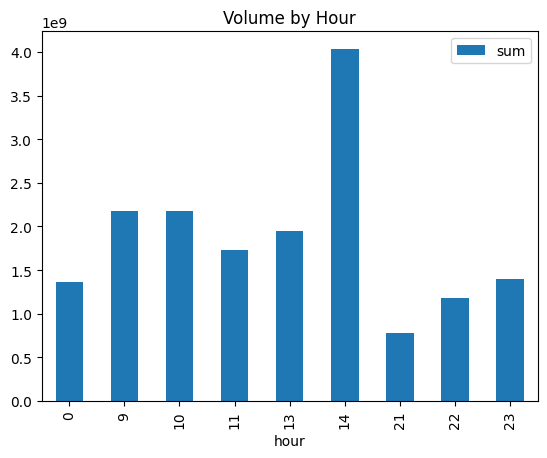

In [ ]:
desc_df['vol'].plot(kind='bar', title='Volume by Hour')

<Axes: title={'center': 'Future 2min Return by Hour'}, xlabel='hour'>

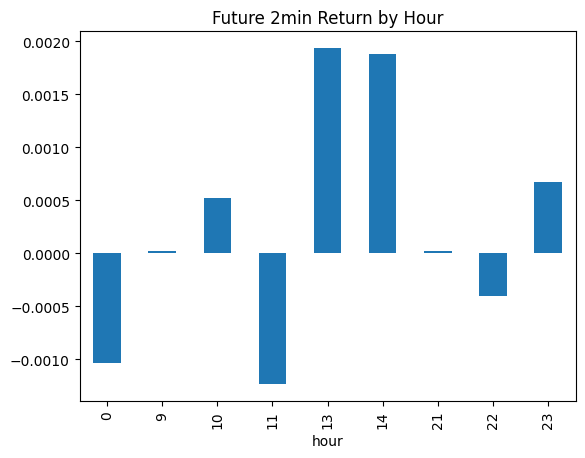

In [13]:
desc_df['return']['mean'].plot(kind='bar', title='Future 2min Return by Hour')

## 特征工程

In [14]:
data['mid_price'] = (data['pb1'] + data['pa1'])/2
data['spread'] = data['pa1'] - data['pb1']
data['bid_depth'] = data['vb1']+data['vb2']+data['vb3']+data['vb4']+data['vb5']
data['ask_depth'] = data['va1']+data['va2']+data['va3']+data['va4']+data['va5']
data['total_depth'] = data['bid_depth'] + data['ask_depth'] 
data['order_imbalance'] = (data['bid_depth']-data['ask_depth'])/(data['bid_depth']+data['ask_depth'])
data['OI_MA_10'] = data['order_imbalance'].rolling(window=10).mean()
data['OI_MA_120'] = data['order_imbalance'].rolling(window=120).mean()
data['OI_momentum_10'] = data['order_imbalance'].diff(10)
data['OI_momentum_120'] = data['order_imbalance'].diff(120)
data['OI_cumulative_10'] = data['order_imbalance'].rolling(window=10).sum()
data['OI_cumulative_120'] = data['order_imbalance'].rolling(window=120).sum()
data['market_pressure'] = (data['pb1']*data['vb1']-data['pa1']*data['va1'])/(data['pb1']*data['vb1']+data['pa1']*data['va1'])
data['SOIR1'] = (data['vb1']-data['va1'])/(data['vb1']+data['va1'])
data['SOIR2'] = (data['vb2']-data['va2'])/(data['vb2']+data['va2'])
data['SOIR3'] = (data['vb3']-data['va3'])/(data['vb3']+data['va3'])
data['SOIR4'] = (data['vb4']-data['va4'])/(data['vb4']+data['va4'])
data['SOIR5'] = (data['vb5']-data['va5'])/(data['vb5']+data['va5'])
data['bid_ask_volume_ratio'] = (data['vb1']+data['vb2']+data['vb3']+data['vb4']+data['vb5'])/(data['va1']+data['va2']+data['va3']+data['va4']+data['va5'])
data['relative_spread'] = (data['pa1'] - data['pb1'])/((data['pa1'] + data['pb1'])/2)
data['OI_std_10'] = data['order_imbalance'].rolling(window=10).std()
data['OI_std_120'] = data['order_imbalance'].rolling(window=120).std()
data['OI_skew_10'] = data['order_imbalance'].rolling(window=10).skew()
data['SOIR'] = data['SOIR1']+data['SOIR2']+data['SOIR3']+data['SOIR4']+data['SOIR5']
data['SOIR_weighted'] = 5*data['SOIR1']+4*data['SOIR2']+3*data['SOIR3']+2*data['SOIR4']+data['SOIR5']
data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,SOIR3,SOIR4,SOIR5,bid_ask_volume_ratio,relative_spread,OI_std_10,OI_std_120,OI_skew_10,SOIR,SOIR_weighted
0,2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,...,-0.419355,-0.700000,-0.700000,0.365217,0.000302,NaN,NaN,NaN,-2.366974,-5.596160
1,2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,...,-0.437500,-0.619048,-0.924528,0.263636,0.000302,NaN,NaN,NaN,-2.652504,-6.232266
2,2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,...,-0.058824,-0.789474,-0.294118,0.341667,0.000151,NaN,NaN,NaN,-1.883156,-4.901387
3,2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,...,-0.630769,-0.571429,-0.200000,0.276119,0.000302,NaN,NaN,NaN,-2.845055,-9.649451
4,2023-10-16 09:00:02.500000+08:00,66220.0,31557.0,66200.0,2.0,66220.0,20.0,66190.0,2.0,66230.0,...,-0.536232,-0.571429,-0.225806,0.285714,0.000302,NaN,NaN,NaN,-2.961173,-10.306364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867050,2023-10-31 23:59:54+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-0.333333,0.200000,-0.600000,0.692308,0.000445,0.000000,0.112671,0.000000,-0.876190,-1.914286
867051,2023-10-31 23:59:54.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-0.333333,0.200000,-0.600000,0.692308,0.000445,0.000000,0.112155,0.000000,-0.876190,-1.914286
867052,2023-10-31 23:59:55+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-0.333333,0.200000,-0.600000,0.692308,0.000445,0.000000,0.111604,0.000000,-0.876190,-1.914286
867053,2023-10-31 23:59:55.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-0.333333,0.200000,-0.600000,0.692308,0.000445,0.000000,0.111018,0.000000,-0.876190,-1.914286


In [15]:
def calculate_direction(P_t, Ask_t, Bid_t):
    """
    根据成交价与最优报价中间价确定买卖方向.
    """
    mid_price = (Ask_t + Bid_t) / 2
    if P_t > mid_price:
        return 1  # 买单
    elif P_t < mid_price:
        return -1  # 卖单
    else:
        return 0  # 无法确定

def calculate_effective_spread(df):
    """
    计算有效价差因子 ES.
    """
    df['D_k'] = df.apply(lambda row: calculate_direction(row['last_price'], row['pa1'], row['pb1']), axis=1)
    df['mid_price_t'] = (df['pa1'] + df['pb1']) / 2
    df['ES'] = 2 * df['D_k'] * (df['last_price'] - df['mid_price_t']) / df['mid_price_t']
    return df['ES']

data['effective_spread'] = calculate_effective_spread(data)

In [16]:
def calculate_ofi(df, bid_price, ask_price, bid_volume, ask_volume):
    # 计算买卖价和买卖量的变化
    delta_bid_vol = np.where(df[bid_price] < df[bid_price].shift(1), -df[bid_volume].shift(1),
                             np.where(df[bid_price] > df[bid_price].shift(1), df[bid_volume],
                                      df[bid_volume] - df[bid_volume].shift(1)))

    delta_ask_vol = np.where(df[ask_price] < df[ask_price].shift(1), df[ask_volume],
                             np.where(df[ask_price] > df[ask_price].shift(1), -df[ask_volume].shift(1),
                                      df[ask_volume] - df[ask_volume].shift(1)))
    # 计算 OFI
    ofi = delta_bid_vol - delta_ask_vol
    return ofi

# 计算不同档位的 OFI
data['OFI1'] = calculate_ofi(data, 'pb1', 'pa1', 'vb1', 'va1')
data['OFI2'] = calculate_ofi(data, 'pb2', 'pa2', 'vb2', 'va2')
data['OFI3'] = calculate_ofi(data, 'pb3', 'pa3', 'vb3', 'va3')
data['OFI4'] = calculate_ofi(data, 'pb4', 'pa4', 'vb4', 'va4')
data['OFI5'] = calculate_ofi(data, 'pb5', 'pa5', 'vb5', 'va5')
data['MOFI'] = data['OFI1']+data['OFI2']+data['OFI3']+data['OFI4']+data['OFI5']
data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,D_k,mid_price_t,ES,effective_spread,OFI1,OFI2,OFI3,OFI4,OFI5,MOFI
0,2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,...,1,66190.0,0.000302,0.000302,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,...,1,66190.0,0.000302,0.000302,0.0,-1.0,-1.0,1.0,2.0,1.0
2,2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,...,-1,66205.0,0.000151,0.000151,20.0,6.0,39.0,23.0,63.0,151.0
3,2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,...,-1,66210.0,0.000302,0.000302,4.0,25.0,14.0,51.0,22.0,116.0
4,2023-10-16 09:00:02.500000+08:00,66220.0,31557.0,66200.0,2.0,66220.0,20.0,66190.0,2.0,66230.0,...,1,66210.0,0.000302,0.000302,0.0,-1.0,4.0,0.0,-1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867050,2023-10-31 23:59:54+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-1,67455.0,0.003706,0.003706,0.0,0.0,0.0,0.0,0.0,0.0
867051,2023-10-31 23:59:54.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-1,67455.0,0.003706,0.003706,0.0,0.0,0.0,0.0,0.0,0.0
867052,2023-10-31 23:59:55+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-1,67455.0,0.003706,0.003706,0.0,0.0,0.0,0.0,0.0,0.0
867053,2023-10-31 23:59:55.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,-1,67455.0,0.003706,0.003706,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

def hurst_exponent(volume_series):
    T = len(volume_series)
    # mean_volume = np.mean(volume_series)
    # # 累计偏差序列
    # Y = np.cumsum(volume_series - mean_volume)
    # 不同子序列长度 n
    n_values = [10, 20, 50, 100]
    F_n = []
    
    for n in n_values:
        segments = int(T // n)
        F_segment = []
        
        for i in range(segments):
            segment = volume_series[i * n:(i + 1) * n]
            mean_value = segment.mean()
            deviation = (segment - mean_value).cumsum()
            maxi = deviation.max()
            mini = deviation.min()
            sigma = segment.std()
            if sigma == 0:
                F_segment.append(0)
            else:
                RS = (maxi - mini)/sigma
                F_segment.append(RS)
        
        F_n.append(np.mean(F_segment))

    # 标度关系：log-log回归
    log_n = np.log(n_values)
    log_F_n = np.log(F_n)
    hurst, _ = linregress(log_n, log_F_n)[:2]
    return hurst

from joblib import Parallel, delayed
# 滚动窗口的并行计算
def parallel_rolling_hurst(data, window, n_jobs=-1):
    results = Parallel(n_jobs=n_jobs)(
        delayed(hurst_exponent)(data.iloc[i:i+window].values)
        for i in range(len(data) - window + 1)
    )
    return [np.nan] * (window - 1) + results

for i in range(1, 6):
    data['hurst_bid{}'.format(i)] = parallel_rolling_hurst(data['vb{}'.format(i)], window=300)
    data['hurst_ask{}'.format(i)] = parallel_rolling_hurst(data['va{}'.format(i)], window=300)

data['hurst_mean_bid'] = (data['hurst_bid1'] + data['hurst_bid2'] + data['hurst_bid3'] + data['hurst_bid4'] + data['hurst_bid5'])/5
data['hurst_mean_ask'] = (data['hurst_ask1'] + data['hurst_ask2'] + data['hurst_ask3'] + data['hurst_ask4'] + data['hurst_ask5'])/5
data['hurst_mean'] = (data['hurst_bid1'] + data['hurst_bid2'] + data['hurst_bid3'] + data['hurst_bid4'] + data['hurst_bid5'] + 
                      data['hurst_ask1'] + data['hurst_ask2'] + data['hurst_ask3'] + data['hurst_ask4'] + data['hurst_ask5'])/10
data['hurst_diff_bid'] = data['hurst_bid1'] - data['hurst_bid5']
data['hurst_diff_ask'] = data['hurst_ask1'] - data['hurst_ask5']
data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,hurst_ask3,hurst_bid4,hurst_ask4,hurst_bid5,hurst_ask5,hurst_mean_bid,hurst_mean_ask,hurst_mean,hurst_diff_bid,hurst_diff_ask
0,2023-10-16 09:00:00.500000+08:00,66200.0,31458.0,66180.0,20.0,66200.0,22.0,66170.0,1.0,66210.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-10-16 09:00:01+08:00,66200.0,31504.0,66180.0,13.0,66200.0,15.0,66170.0,1.0,66210.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-10-16 09:00:01.500000+08:00,66200.0,31524.0,66200.0,5.0,66210.0,4.0,66190.0,2.0,66220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-10-16 09:00:02+08:00,66200.0,31545.0,66200.0,5.0,66220.0,23.0,66190.0,2.0,66230.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-10-16 09:00:02.500000+08:00,66220.0,31557.0,66200.0,2.0,66220.0,20.0,66190.0,2.0,66230.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867050,2023-10-31 23:59:54+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,1.982796,1.472816,1.218101,1.498359,1.865355,1.482385,1.616649,1.549517,0.061042,-0.414540
867051,2023-10-31 23:59:54.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,1.854649,1.430541,1.218101,1.452004,1.766958,1.458652,1.575056,1.516854,0.075562,-0.227371
867052,2023-10-31 23:59:55+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,1.816952,1.403546,1.133168,1.408298,1.739921,1.440326,1.552962,1.496644,0.200250,-0.170436
867053,2023-10-31 23:59:55.500000+08:00,67330.0,2305.0,67440.0,15.0,67470.0,20.0,67430.0,5.0,67480.0,...,1.808152,1.382296,1.133168,1.369382,1.734209,1.417081,1.534342,1.475712,0.221606,-0.153142


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

data = pd.read_pickle("features.pkl")
data_new = data.copy()

# 按天分组
data_new['date'] = data_new['trade_time'].dt.date
data_new['hour'] = data_new['trade_time'].dt.hour

# 去掉夜盘数据（只保留 8:00~16:00 的数据）
data_new = data_new[(data_new['hour'] >= 8) & (data_new['hour'] < 16)]
data_new.drop(["instrumentid"], inplace=True, axis=1)

unique_dates = data_new['trade_time'].dt.date.unique()
standardized_features = []

for date in unique_dates:
    date_data = data_new[data_new.date == date].copy()
    feature_columns = date_data.columns.tolist()[2:-2]
    
    date_data['return'] = date_data['last_price'].shift(-6) / date_data['last_price'] - 1
    date_data.dropna(inplace=True, axis=0)
    
    for col in feature_columns:
        rolling_mean = date_data[col].expanding().mean()
        rolling_std = date_data[col].expanding().std()
        date_data[col] = (date_data[col] - rolling_mean) / rolling_std
    
    date_data = date_data.iloc[5:, :]
    standardized_features.append(date_data)

standardized_features = pd.concat(standardized_features, axis=0)

standardized_features = standardized_features.fillna(0)

standardized_features

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,hurst_bid5,hurst_ask5,hurst_mean_bid,hurst_mean_ask,hurst_mean,hurst_diff_bid,hurst_diff_ask,date,hour,return
304,2023-10-16 09:02:32.500000+08:00,66250.0,1.287657,-0.645497,1.064405,-1.290994,-1.290623,-0.645497,0.589448,-1.290994,...,1.682678,1.864383,1.648257,1.786871,1.775044,-1.846333,-0.517308,2023-10-16,9,-0.000151
305,2023-10-16 09:02:33+08:00,66250.0,1.606413,-0.585540,-0.612372,-1.069045,-0.446722,-0.585540,0.537682,-1.069045,...,1.373852,1.913653,1.151716,1.759159,1.557074,-1.283772,-1.310888,2023-10-16,9,0.000000
306,2023-10-16 09:02:33.500000+08:00,66250.0,1.523583,-1.755426,2.083165,-0.935414,0.568292,-1.755426,-0.482828,-0.935414,...,0.855874,0.902783,0.756424,1.011681,0.935645,-0.766975,-0.841248,2023-10-16,9,0.000000
307,2023-10-16 09:02:34+08:00,66260.0,1.365617,-0.184900,-1.325178,-0.843274,0.466266,-0.184900,0.591692,-0.843274,...,0.020888,0.446713,-0.265779,0.303435,0.075774,0.186588,-1.403010,2023-10-16,9,-0.000151
308,2023-10-16 09:02:34.500000+08:00,66250.0,1.233808,-1.500000,1.637966,-0.774597,0.573633,-1.500000,-0.541002,-0.774597,...,-0.565570,-0.016641,-0.952126,-0.211123,-0.543716,0.886987,-1.168240,2023-10-16,9,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845437,2023-10-31 14:54:48+08:00,67410.0,1.759842,0.581903,-0.599417,0.545873,-0.691055,0.584838,0.033189,0.544737,...,0.699491,0.321943,1.264560,2.269150,1.894777,-0.112458,1.132385,2023-10-31,14,0.000000
845438,2023-10-31 14:54:48.500000+08:00,67410.0,1.759700,0.581887,-0.599401,0.545859,-0.691035,0.584823,0.033188,0.544723,...,1.050944,0.549674,1.557641,2.551226,2.205885,-0.499021,1.052106,2023-10-31,14,0.000000
845439,2023-10-31 14:54:49+08:00,67410.0,1.759559,0.581872,-0.599385,0.545845,-0.691015,0.584808,0.033187,0.544709,...,2.467706,1.295029,2.747156,2.781750,2.988340,-2.070119,0.187588,2023-10-31,14,0.000000
845440,2023-10-31 14:54:49.500000+08:00,67410.0,1.759417,0.581857,-0.599369,0.545831,-0.690995,0.584792,0.033187,0.544695,...,2.246437,0.570977,2.496376,2.189239,2.537714,-1.621041,0.798051,2023-10-31,14,0.000000


In [38]:
standardized_features.date.unique()

array([datetime.date(2023, 10, 16), datetime.date(2023, 10, 17),
       datetime.date(2023, 10, 18), datetime.date(2023, 10, 19),
       datetime.date(2023, 10, 20), datetime.date(2023, 10, 21),
       datetime.date(2023, 10, 23), datetime.date(2023, 10, 24),
       datetime.date(2023, 10, 25), datetime.date(2023, 10, 26),
       datetime.date(2023, 10, 27), datetime.date(2023, 10, 28),
       datetime.date(2023, 10, 30), datetime.date(2023, 10, 31)],
      dtype=object)

In [ ]:
#最后两个交易日的数据作为测试集，前边作为验证集
datelist = list(standardized_features.date.unique())
train_data = standardized_features[standardized_features.date<datelist[-2]]
test_data = standardized_features[standardized_features.date>=datelist[-2]]
train_data

,trade_time,last_price,vol,pb1,vb1,pa1,va1,pb2,vb2,pa2,...,hurst_bid5,hurst_ask5,hurst_mean_bid,hurst_mean_ask,hurst_mean,hurst_diff_bid,hurst_diff_ask,date,hour,return
304,2023-10-16 09:02:32.500000+08:00,66250.0,1.287657,-0.645497,1.064405,-1.290994,-1.290623,-0.645497,0.589448,-1.290994,...,1.682678,1.864383,1.648257,1.786871,1.775044,-1.846333,-0.517308,2023-10-16,9,-0.000151
305,2023-10-16 09:02:33+08:00,66250.0,1.606413,-0.585540,-0.612372,-1.069045,-0.446722,-0.585540,0.537682,-1.069045,...,1.373852,1.913653,1.151716,1.759159,1.557074,-1.283772,-1.310888,2023-10-16,9,0.000000
306,2023-10-16 09:02:33.500000+08:00,66250.0,1.523583,-1.755426,2.083165,-0.935414,0.568292,-1.755426,-0.482828,-0.935414,...,0.855874,0.902783,0.756424,1.011681,0.935645,-0.766975,-0.841248,2023-10-16,9,0.000000
307,2023-10-16 09:02:34+08:00,66260.0,1.365617,-0.184900,-1.325178,-0.843274,0.466266,-0.184900,0.591692,-0.843274,...,0.020888,0.446713,-0.265779,0.303435,0.075774,0.186588,-1.403010,2023-10-16,9,-0.000151
308,2023-10-16 09:02:34.500000+08:00,66250.0,1.233808,-1.500000,1.637966,-0.774597,0.573633,-1.500000,-0.541002,-0.774597,...,-0.565570,-0.016641,-0.952126,-0.211123,-0.543716,0.886987,-1.168240,2023-10-16,9,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655519,2023-10-28 09:02:16+08:00,67330.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.262000,-0.705902,0.259197,-0.607785,-0.131944,-0.327493,1.757687,2023-10-28,9,0.000000
655520,2023-10-28 09:02:16.500000+08:00,67330.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.261490,-0.897619,0.182302,-0.847553,-0.300401,-0.036135,1.960064,2023-10-28,9,0.000000
655521,2023-10-28 09:02:17+08:00,67330.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.113177,-1.058635,-0.098664,-1.052695,-0.584117,0.393973,2.123920,2023-10-28,9,0.000000
655522,2023-10-28 09:02:17.500000+08:00,67330.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.112970,-1.197491,0.060797,-1.209033,-0.559574,1.626803,2.259412,2023-10-28,9,0.000000


In [ ]:
#保存数据
train_data.to_pickle("Train_data.pkl")
test_data.to_pickle("Test_data.pkl")